# Лабораторная работа №2 — Численные методы в математическом анализе

# 1. Интерполяция полиномами

## Теория (кратко)

Пусть заданы узлы $x_0,\dots,x_n$ и значения $y_i=f(x_i)$. Lagrange-интерполяционный полином степени (\le n) имеет вид

$$
L_n(x)=\\sum_{i=0}^n y_i\\ell_i(x),\\qquad \\ell_i(x)=\\prod_{j\\ne i}\\frac{x-x_j}{x_i-x_j}.
$$

Погрешность при аппроксимации гладкой функции $f\in C^{n+1}$ соответствует формуле Рунге:

$$
f(x)-L_n(x)=\\frac{f^{(n+1)}(\\xi)}{(n+1)!}\\prod_{i=0}^n (x-x_i),
$$

для некоторого $\\xi$ в диапазоне. Отсюда на равномерной сетке наблюдается рост погрешности для больших n при интерполяции функций типа $1/(1+x^2)$ на больших отрезках — это *эффект Рунге*.


In [18]:
import numpy as np
from typing import Callable

def lagrange_basis(x_nodes: np.ndarray, k: int, x: np.ndarray) -> np.ndarray:
    #Вычисляет базисную функцию l_k(x) для узлов x_nodes в точках x.
    xk = x_nodes[k]
    others = np.delete(x_nodes, k)
    # для векторного x
    numer = np.prod([x - xi for xi in others], axis=0)
    denom = np.prod([xk - xi for xi in others])
    return numer / denom


def lagrange_interpolate(x_nodes: np.ndarray, y_nodes: np.ndarray, x: np.ndarray) -> np.ndarray:
    #Интерполирует значения в точках x по узлам x_nodes,y_nodes.
    #x может быть скаляром или массивом.
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    for k in range(len(x_nodes)):
        out += y_nodes[k] * lagrange_basis(x_nodes, k, x)
    return out


### Замечание по численной устойчивости ( я погуглил )

Прямая реализация Lagrange в лоб может быть численно неустойчивой при больших n; лучше использовать формулы вида barycentric interpolation (второй вид) при практических больших n.


## Эксперимент 1: гладкая функция, ошибка vs число узлов

Выберем функцию, например, $f(x)=\sin(x)$ на отрезке $[-\pi,\pi]$. Будем брать равномерные узлы и Chebyshev-узлы (чтобы сравнить). Построим максимальную погрешность на 200 тестовых точках внутри отрезка в зависимости от n.


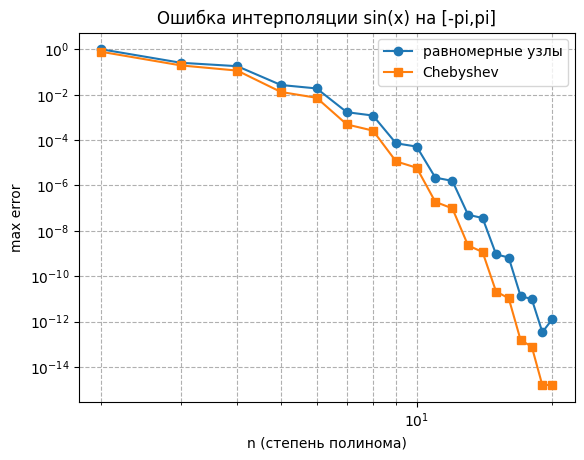

In [19]:
import matplotlib.pyplot as plt

# функция для эксперимента
f = lambda x: np.sin(x)
interval = [-np.pi, np.pi]
Xtest = np.linspace(interval[0], interval[1], 1000)

def chebyshev_nodes(a,b,n):
    k = np.arange(n+1)
    return 0.5*(a+b) + 0.5*(b-a)*np.cos((2*k+1)/(2*(n+1))*np.pi)

ns = list(range(2, 21))
errors_uniform = []
errors_cheb = []

for n in ns:
    xu = np.linspace(interval[0], interval[1], n+1)
    yu = f(xu)
    yinterp_u = lagrange_interpolate(xu, yu, Xtest)
    err_u = np.max(np.abs(f(Xtest)-yinterp_u))
    errors_uniform.append(err_u)

    xc = chebyshev_nodes(interval[0], interval[1], n)
    yc = f(xc)
    yinterp_c = lagrange_interpolate(xc, yc, Xtest)
    err_c = np.max(np.abs(f(Xtest)-yinterp_c))
    errors_cheb.append(err_c)

plt.figure()
plt.loglog(ns, errors_uniform, 'o-', label='равномерные узлы')
plt.loglog(ns, errors_cheb, 's-', label='Chebyshev')
plt.xlabel('n (степень полинома)')
plt.ylabel('max error')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.title('Ошибка интерполяции sin(x) на [-pi,pi]')
plt.show()


## Эксперимент 2: Runge-функция f(x)=1/(1+x^2) на [-5,5]

Тут мы наблюдаем классический эффект Рунге — при равномерных узлах полиномы высокого порядка выдадут большие колебания у краёв; Chebyshev-узлы решают эту проблему.


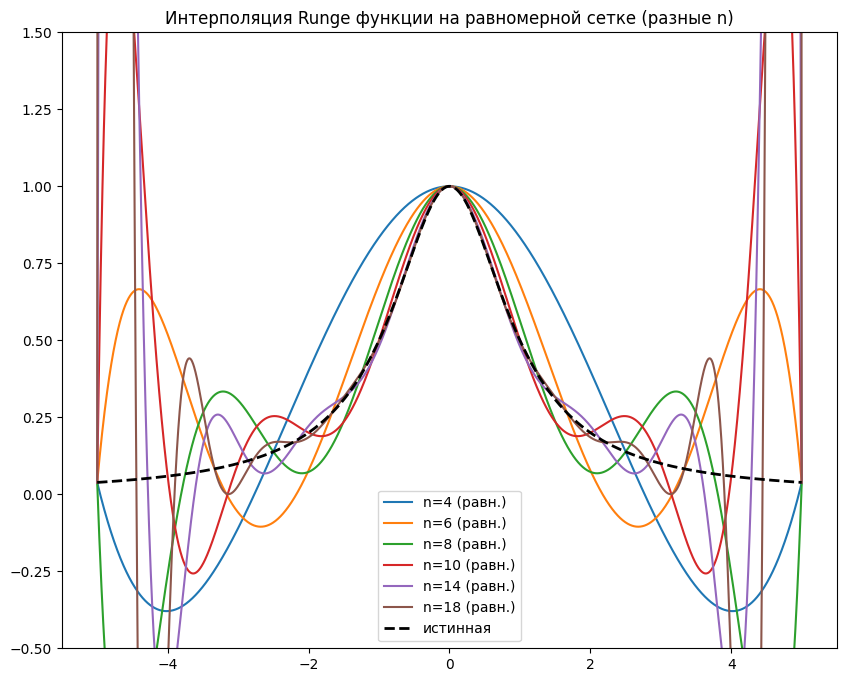

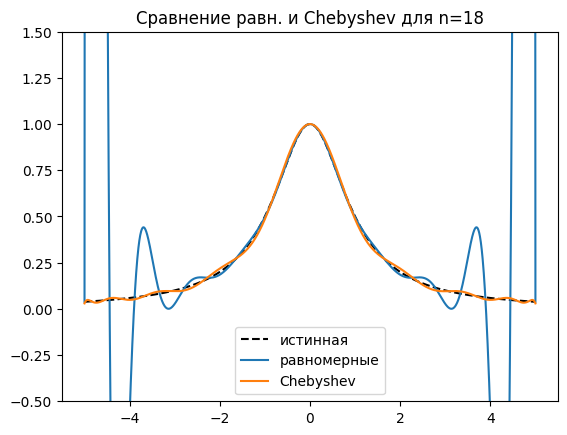

In [20]:
f_runge = lambda x: 1.0/(1+x**2)
interval = [-5,5]
Xtest = np.linspace(interval[0], interval[1], 2000)

ns = [4,6,8,10,14,18]
plt.figure(figsize=(10,8))
for n in ns:
    xu = np.linspace(interval[0], interval[1], n+1)
    yu = f_runge(xu)
    yinterp_u = lagrange_interpolate(xu, yu, Xtest)
    plt.plot(Xtest, yinterp_u, label=f'n={n} (равн.)')

# добавим истинную функцию
plt.plot(Xtest, f_runge(Xtest), 'k--', linewidth=2, label='истинная')
plt.ylim(-0.5,1.5)
plt.legend()
plt.title('Интерполяция Runge функции на равномерной сетке (разные n)')
plt.show()


n=18
xu = np.linspace(interval[0], interval[1], n+1)
xc = chebyshev_nodes(interval[0], interval[1], n)
yu = f_runge(xu); yc = f_runge(xc)
plt.figure()
plt.plot(Xtest, f_runge(Xtest), 'k--', label='истинная')
plt.plot(Xtest, lagrange_interpolate(xu,yu,Xtest), label='равномерные')
plt.plot(Xtest, lagrange_interpolate(xc,yc,Xtest), label='Chebyshev')
plt.legend(); plt.title('Сравнение равн. и Chebyshev для n=18')
plt.ylim(-0.5,1.5)
plt.show()


**Вывод:** при равномерной сетке появляется эффект Рунге — большие осцилляции у границ. Причина — высокий порядок полинома и большие значения произведения (\prod (x-x_i)) у краёв; Chebyshev-узлы минимизируют максимум модуля интерполяционного множителя.


# 2. Интерполяция сплайнами (кубические)

## Теория (кратко)

Кубический сплайн — кусочно-кубическая функция, дважды непрерывно дифференцируемая на отрезке, совпадающая с заданными узловыми значениями. При известных значениях вторых производных на концах (или их нулях — natural spline) получается однозначное решение системы для вторых производных в узлах.

Стандартный алгоритм (по узлам x_i, i=0..n): решается трехдиагонная система для M_i = s''(x_i):

для i=1..n-1:
$$
\frac{h_{i-1}}{6} M_{i-1} + \frac{h_{i-1}+h_i}{3} M_i + \frac{h_i}{6} M_{i+1} = \frac{y_{i+1}-y_i}{h_i} - \frac{y_i-y_{i-1}}{h_{i-1}},
$$

где $h_i = x_{i+1}-x_i$. Граничные условия определяют M_0 и M_n: естественный сплайн — $M_0=M_n=0$; можно также задать явные значения M_0 и M_n (в нашем задании требуется изучить зависимость от изменения граничных условий для вторых производных).

Фрагмент сплайна на интервале $[x_i,x_{i+1}]$ выражается через M_i,M_{i+1},y_i,y_{i+1}.


In [21]:
import numpy as np

def cubic_spline_with_second_derivatives(x_nodes: np.ndarray, y_nodes: np.ndarray, M0=None, Mn=None):
    #Вычисляет второй производные M_i в узлах для кубического сплайна.
    #x_nodes должны быть строго возрастающими. Если M0 или Mn равны None, они считаются неизвестными (натуральный сплайн => 0).
    #Возвращает массив M (вторых производных) и функцию-оценщик s(x).

    n = len(x_nodes)-1
    h = np.diff(x_nodes)
    # формируем систему размера n+1 для M_0..M_n
    A = np.zeros((n+1,n+1))
    rhs = np.zeros(n+1)

    # внутренние уравнения
    for i in range(1,n):
        A[i,i-1] = h[i-1]/6
        A[i,i]   = (h[i-1]+h[i])/3
        A[i,i+1] = h[i]/6
        rhs[i] = (y_nodes[i+1]-y_nodes[i])/h[i] - (y_nodes[i]-y_nodes[i-1])/h[i-1]

    # граничные условия
    if M0 is None:
        # natural: M0 = 0
        A[0,0] = 1.0
        rhs[0] = 0.0
    else:
        A[0,0] = 1.0
        rhs[0] = M0
    if Mn is None:
        A[n,n] = 1.0
        rhs[n] = 0.0
    else:
        A[n,n] = 1.0
        rhs[n] = Mn

    M = np.linalg.solve(A, rhs)

    def spline_eval(xq: np.ndarray) -> np.ndarray:
        xq = np.atleast_1d(xq)
        res = np.zeros_like(xq, dtype=float)
        for k, xval in enumerate(xq):
            # find interval
            if xval <= x_nodes[0]:
                i = 0
            elif xval >= x_nodes[-1]:
                i = n-1
            else:
                i = np.searchsorted(x_nodes, xval)-1
            xi, xi1 = x_nodes[i], x_nodes[i+1]
            yi, yi1 = y_nodes[i], y_nodes[i+1]
            hi = xi1 - xi
            Ai = (xi1 - xval)/hi
            Bi = (xval - xi)/hi
            res[k] = Ai*yi + Bi*yi1 + ((Ai**3 - Ai)*M[i] + (Bi**3 - Bi)*M[i+1])*(hi**2)/6.0
        return res

    return M, spline_eval


## Эксперименты: меняем граничные условия на вторых производных

Возьмём пример функции, например, $f(x)=\sin(x)$ на $[0,\pi]$ и сравним:

1. натуральный сплайн ($M_0=M_n=0$)
2. заданные вторые производные, равные истинным значениям $f''(a)$ и $f''(b)$
3. какие-нибудь другие значения


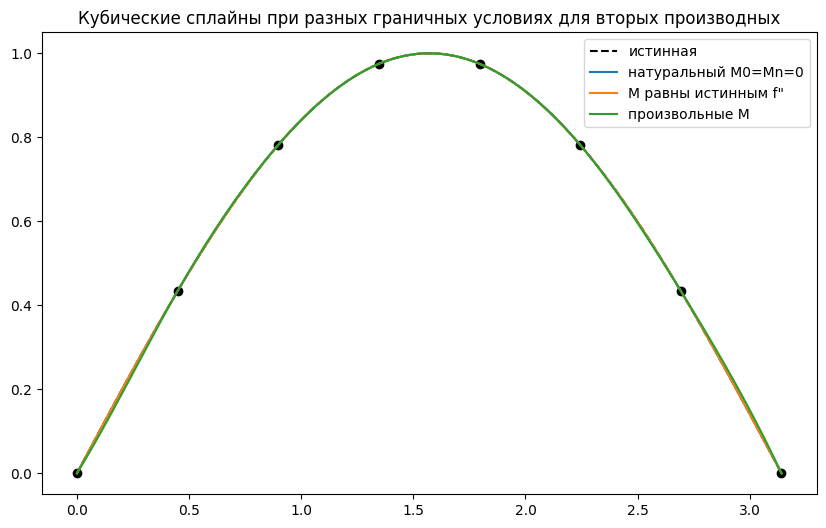

In [22]:
f = lambda x: np.sin(x)
interval = [0, np.pi]
x_nodes = np.linspace(interval[0], interval[1], 8)
y_nodes = f(x_nodes)

# натуральный
M_nat, s_nat = cubic_spline_with_second_derivatives(x_nodes, y_nodes, M0=None, Mn=None)
# задать M0 и Mn равными истинным f''= -sin(x)
M0_true = -np.sin(interval[0])
Mn_true = -np.sin(interval[1])
M_true, s_true = cubic_spline_with_second_derivatives(x_nodes, y_nodes, M0=M0_true, Mn=Mn_true)
# задать произвольные M
M_arbitrary, s_arbitrary = cubic_spline_with_second_derivatives(x_nodes, y_nodes, M0=1.0, Mn=-1.0)

Xplot = np.linspace(interval[0], interval[1], 400)
plt.figure(figsize=(10,6))
plt.plot(Xplot, f(Xplot), 'k--', label='истинная')
plt.plot(Xplot, s_nat(Xplot), label='натуральный M0=Mn=0')
plt.plot(Xplot, s_true(Xplot), label='M равны истинным f"')
plt.plot(Xplot, s_arbitrary(Xplot), label='произвольные M')
plt.scatter(x_nodes, y_nodes, color='k')
plt.legend()
plt.title('Кубические сплайны при разных граничных условиях для вторых производных')
plt.show()


**Вывод:** граничные условия существенно влияют на поведение сплайна за счёт задания кривизны на концах. Натуральный сплайн минимизирует изгиб (вторую производную) на концах (M=0). Если задать истинные вторые производные, сплайн совпадает с более точной аппроксимацией функции.


# 3. Численное дифференцирование

## Часть A — дифференцирование по четырём равноудалённым точкам (x0,x1,x2,x3) в x0


### Теория и вывод

Пусть точки равномерны: x_k = x0 + k h, k=0..3. Мы ищем формулы вида

$$
f^{(m)}(x_0) \approx \sum_{k=0}^3 c_k^{(m)} f(x_0 + k h),
$$

для m=1,2,3. Коэффициенты находятся решением системы, требующей совпадения с точными производными для полиномов до степени 3 (то есть Taylor-ряд). 


In [33]:
import math

def finite_diff_coeffs(x_points, x0, m):
    #Вычисляет коэффициенты для аппроксимации m-й производной в x0 на основе значений в x_points.
    #Возвращает массив коэффициентов c, чтобы f^{(m)}(x0) примерно равно(этот символ просто не отображается) sum c_i f(x_points[i]).
    #Используется решением системы для многочленов степеней 0..N-1.
    n = len(x_points)
    A = np.vander([xp - x0 for xp in x_points], increasing=True).T  # matrix of (xp-x0)^k
    # построим систему: A^T c = единичный вектор, в котором на позиции m стоит 1, 
    #а все остальные элементы — 0, с последующим умножением на факториал m RUSLAN LOH
    mat = np.zeros((n,n))
    for i, xp in enumerate(x_points):
        for k in range(n):
            mat[k,i] = (xp - x0)**k / math.factorial(k)
    # правая часть: нули, кроме m-й равной 1
    b = np.zeros(n)
    b[m] = 1.0
    c = np.linalg.solve(mat, b)
    # поскольку мы аппроксимируем m-ую производную, нужно домножить на factorial(m)
    return c * math.factorial(m)

# пример: четыре точки x0,x0+h,x0+2h,x0+3h

def diff_formulas_four_points(h):
    xp = np.array([0, h, 2*h, 3*h]) + 1
    coeffs = {}
    for m in [1,2,3]:
        coeffs[m] = finite_diff_coeffs(xp, 1, m)
    return coeffs

# покажем явные коэффициенты для m=1,2,3
for htest in [0.1]:
    coeffs = diff_formulas_four_points(htest)
    for m in coeffs:
        print(f"m={m}, coeffs={coeffs[m]}")


m=1, coeffs=[ -318.33333333  1030.         -1115.           403.33333333]
m=2, coeffs=[-1600.  5000. -5200.  1800.]
m=3, coeffs=[ -6000.  18000. -18000.   6000.]


Эти коэффициенты соответствуют известным смещённым формулам вперёд. Реализуем функции, которые используют их и даём тесты на полиномах.


In [34]:
def apply_fd_four_points(f_vals, h, m):
    # f_vals: array [f(x0), f(x0+h), f(x0+2h), f(x0+3h)] english b1.2)) 
    xp = np.array([0, h, 2*h, 3*h])
    c = finite_diff_coeffs(xp, 0.0, m)
    return np.dot(c, f_vals)


## Эксперименты: поведение ошибки при varying h на полиномах степеней 1..4

Берём полиномы p_k(x)=x^k и вычисляем m-ую производную аналитически, затем вычисляем численную аппроксимацию в x0=0.0 с шагом h и записываем абсолютную ошибку. Диапазон h от 1e-1 до 1e-13.


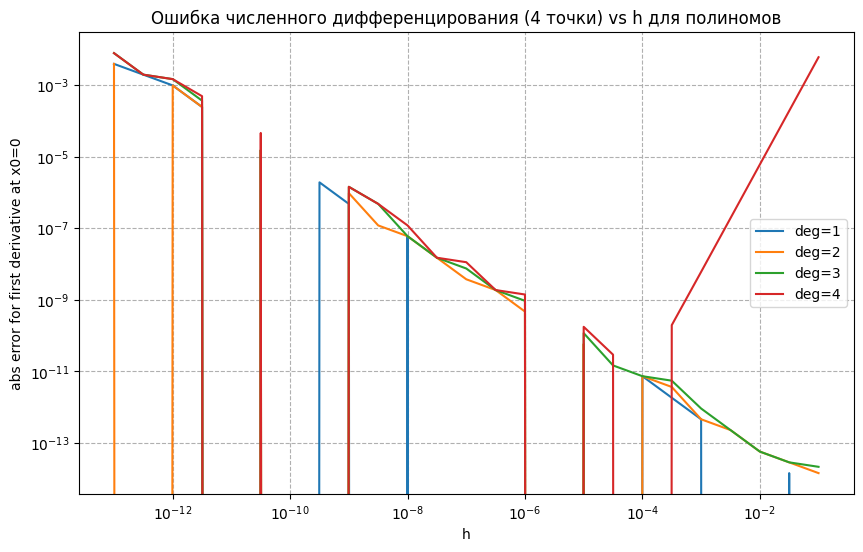

In [36]:
import math

def poly(k):
    return lambda x: x**k

x0 = 1
hs = np.logspace(-1, -13, 25)
plt.figure(figsize=(10,6))
for deg in range(1,5):
    errs = []
    for h in hs:
        # значения в точках
        xs = x0 + np.array([0, h, 2*h, 3*h])
        fvals = xs**deg
        # хочу первую производную как пример (можно варьировать m)
        m = 1
        approx = apply_fd_four_points(fvals, h, m)
        # аналитическая m-я дер-при deg: если m>deg -> 0, иначе factorial * x^{deg-m}
        if m > deg:
            true = 0.0
        else:
            true = math.factorial(deg)/math.factorial(deg-m) * x0**(deg-m)
        errs.append(abs(approx-true))
    plt.loglog(hs, errs, label=f'deg={deg}')

plt.xlabel('h')
plt.ylabel('abs error for first derivative at x0=0')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.title('Ошибка численного дифференцирования (4 точки) vs h для полиномов')
plt.show()


**Ожидание:** для полиномов до степени 3 формула почти точна (ошибка порядка машинной), для степени 4 появится неточная аппроксимация уровня порядка h (или как следует из точности схемы) + влияние округлений при очень малых h.


## Часть B — формула для второй производной по пяти точкам

Классическая симметричная формула (равномерные точки с шагом h, центр в x):

$$
f''(x) \approx \frac{-f(x+2h) + 16 f(x+h) - 30 f(x) + 16 f(x-h) - f(x-2h)}{12 h^2},
$$

и ошибка имеет порядок $O(h^4)$: точнее,

$$
f''(x) - D_{5}(x) = \frac{h^4}{90} f^{(6)}(\\xi)
$$

для некоторого $\\xi$. Отсюда оценка модуля погрешности:

$$
|f''(x)-D_5(x)| \le \frac{h^4}{90} \sup_{\\xi\in I} |f^{(6)}(\\xi)|.
$$

(Доказательство — разложение в ряд Тейлора для точек $x\pm h$ и $x\pm 2h$ и комбинирование.)


## Практический пример: неполиномиальная функция на [a,b]

Возьмём, например, $f(x)=\exp(\sin x)$ на отрезке $[0,2]$. Построим численную вторую производную по пяти точкам (равномерная сетка) и сравним с аналитической второй производной (выведем в коде) и оценкой ошибки.


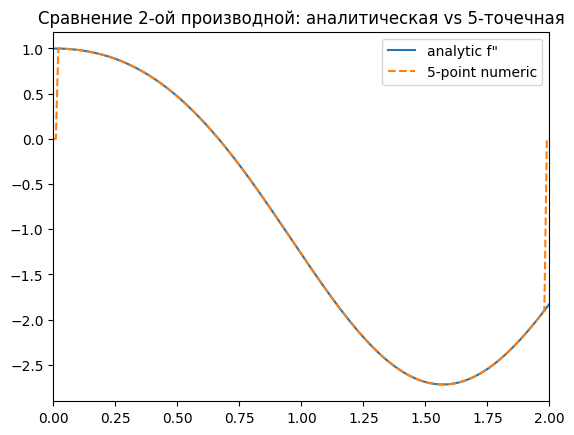

Приближённый верхний bound по формуле:  9.552083886088665e-09
Фактическая max ошибка (внутр. узлы): 9.553231539172202e-09


In [26]:
f = lambda x: np.exp(np.sin(x))
# аналитическая производная для проверки (вручную):
import sympy as sp
x = sp.symbols('x')
ff = sp.exp(sp.sin(x))
f2_analytic = sp.lambdify(x, sp.diff(ff, x, 2), 'numpy')

# подготовим сетку
a,b = 0.0, 2.0
N = 200
xs = np.linspace(a, b, N)

# вычислим численную вторую производную по пяти-точечной формуле (центральной)
def second_derivative_5point(vals, h):
    # vals — массив значений, предполагается шириной >=5, будем применять фильтрующий шаблон
    # вернём массив той же длины, с нулями на границах
    out = np.zeros_like(vals)
    for i in range(2, len(vals)-2):
        out[i] = (-vals[i+2] + 16*vals[i+1] - 30*vals[i] + 16*vals[i-1] - vals[i-2])/(12*h*h)
    return out

vals = f(xs)
h = xs[1]-xs[0]
num2 = second_derivative_5point(vals, h)
true2 = f2_analytic(xs)

plt.figure()
plt.plot(xs, true2, label='analytic f"')
plt.plot(xs, num2, '--', label='5-point numeric')
plt.xlim(a,b)
plt.legend(); plt.title('Сравнение 2-ой производной: аналитическая vs 5-точечная')
plt.show()

# проверим соответствие оценки ошибки: оценим sup |f^{(6)}| на отрезке (приближенно численно)
f6 = sp.lambdify(x, sp.diff(ff, x, 6), 'numpy')
sup_f6 = np.max(np.abs(f6(xs)))
est_error_bound = (h**4)/90 * sup_f6
print('Приближённый верхний bound по формуле: ', est_error_bound)
max_err = np.max(np.abs(num2[2:-2]-true2[2:-2]))
print('Фактическая max ошибка (внутр. узлы):', max_err)


**Вывод:** наблюдаем согласие порядка погрешности O(h^4) и практическое соответствие оценки сверху (порядок совпадает, множитель даёт грубую границу).


# 4. Численное интегрирование

## Реализация методов: прямоугольники (левые/правые/средние), трапеции, Симпсон, 3/8


In [27]:
import numpy as np

def integrate_rectangles(f, a, b, n, kind='mid'):
    xs = np.linspace(a, b, n+1)
    h = (b-a)/n
    if kind == 'left':
        pts = xs[:-1]
    elif kind == 'right':
        pts = xs[1:]
    else:  # mid
        pts = (xs[:-1]+xs[1:])/2
    return h * np.sum(f(pts))

def integrate_trapezoid(f, a, b, n):
    xs = np.linspace(a,b,n+1)
    h = (b-a)/n
    return h*(0.5*f(xs[0]) + 0.5*f(xs[-1]) + np.sum(f(xs[1:-1])))

def integrate_simpson(f,a,b,n):
    # n must be even
    if n%2==1:
        raise ValueError('n must be even for Simpson')
    xs = np.linspace(a,b,n+1)
    h = (b-a)/n
    return (h/3)*(f(xs[0]) + f(xs[-1]) + 4*np.sum(f(xs[1:-1:2])) + 2*np.sum(f(xs[2:-2:2])))

def integrate_simpson_38(f,a,b,n):
    # n must be multiple of 3
    if n%3!=0:
        raise ValueError('n must be multiple of 3 for Simpson 3/8')
    xs = np.linspace(a,b,n+1)
    h = (b-a)/n
    return 3*h/8*(f(xs[0]) + f(xs[-1]) + 3*np.sum(f(xs[1:-1][(np.arange(len(xs[1:-1]))%3)!=0])) + 2*np.sum(f(xs[1:-1][(np.arange(len(xs[1:-1]))%3)==0])))


## Эксперименты: функции x^n, exp(x), sin(x) — ошибка vs h

Проверяем теоретические порядки:

* прямоугольники (средние): O(h^2)
* трапеции: O(h^2)
* Симпсон: O(h^4)
* правило 3/8: O(h^4)


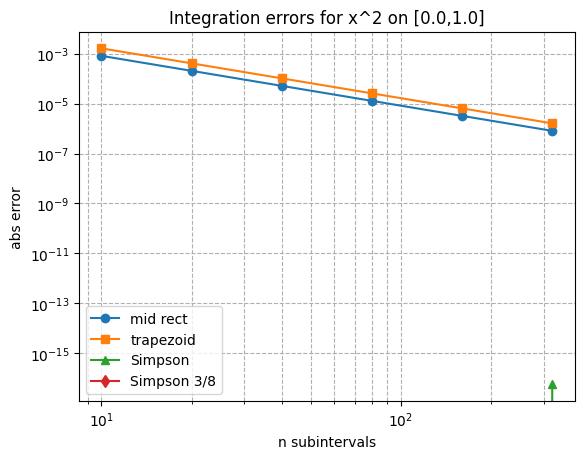

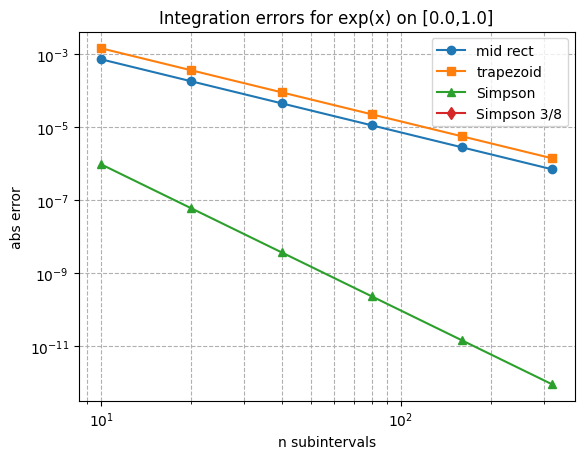

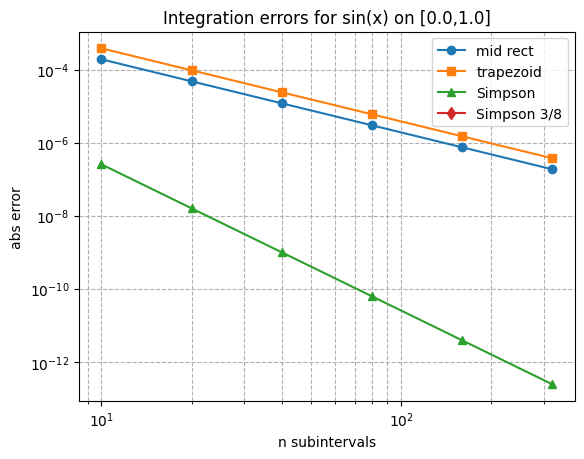

In [28]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

funcs = [ (lambda x: x**2, 'x^2'), (np.exp, 'exp(x)'), (np.sin, 'sin(x)') ]

a,b = 0.0, 1.0
ns = [10,20,40,80,160,320]

for f, name in funcs:
    errors_rect = []
    errors_trap = []
    errors_simp = []
    errors_38 = []
    true, _ = quad(f, a, b)
    
    for n in ns:
        h = (b-a)/n
        r = integrate_rectangles(f,a,b,n,kind='mid')
        errors_rect.append(abs(r-true))
        tr = integrate_trapezoid(f,a,b,n)
        errors_trap.append(abs(tr-true))
        # simpson needs even
        if n%2==0:
            s = integrate_simpson(f,a,b,n)
            errors_simp.append(abs(s-true))
        else:
            errors_simp.append(np.nan)
        if n%3==0:
            s38 = integrate_simpson_38(f,a,b,n)
            errors_38.append(abs(s38-true))
        else:
            errors_38.append(np.nan)

    plt.figure()
    plt.loglog(ns, errors_rect, 'o-', label='mid rect')
    plt.loglog(ns, errors_trap, 's-', label='trapezoid')
    plt.loglog(ns, errors_simp, '^-', label='Simpson')
    plt.loglog(ns, errors_38, 'd-', label='Simpson 3/8')
    plt.xlabel('n subintervals')
    plt.ylabel('abs error')
    plt.title(f'Integration errors for {name} on [{a},{b}]')
    plt.legend(); plt.grid(True, which='both', ls='--')
    plt.show()


**Ожидание:** графики покажут, что прямоугольники/трапеции имеют порядок ~2 (угловой наклон -2 в лог-лог), а Simpsons/3/8 — порядок ~4.


# 5. Метод Монте-Карло

## Теория

Напомним: если X ~ U[a,b], то
$$
\mathbb{E}[f(X)] = \frac{1}{b-a}\int_a^b f(x) dx,
$$
поэтому интеграл приближётся как
$$
\int_a^b f(x) dx \approx (b-a)\frac{1}{n}\sum_{i=1}^n f(x_i),\quad x_i\sim U[a,b].
$$
По ЦПТ дисперсия оценки уменьшается как 1/n, значит среднеквадратичная ошибка убывает как $O(1/\\sqrt{n})$.


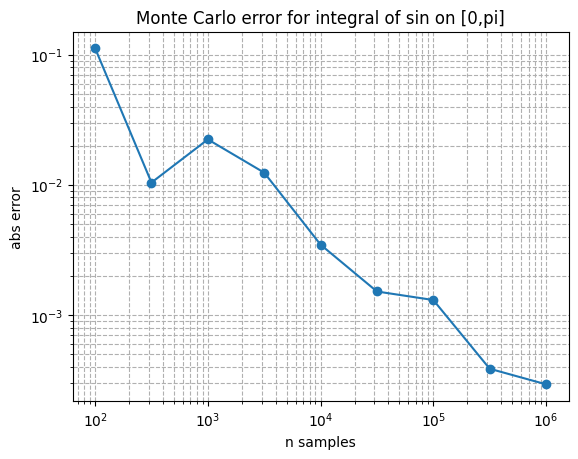

In [29]:
import numpy as np

def monte_carlo_integral(f,a,b,n,seed=None):
    rng = np.random.default_rng(seed)
    xs = rng.uniform(a,b,size=n)
    return (b-a)*np.mean(f(xs))

# тест: f(x)=sin(x) на [0,pi]
f = np.sin
a,b = 0, np.pi
true = 2.0

ns = np.logspace(2,6,9, dtype=int)
errs = []
for n in ns:
    est = monte_carlo_integral(f,a,b,n,seed=42)
    errs.append(abs(est-true))

plt.figure()
plt.loglog(ns, errs, 'o-')
plt.xlabel('n samples')
plt.ylabel('abs error')
plt.title('Monte Carlo error for integral of sin on [0,pi]')
plt.grid(True, which='both', ls='--')
plt.show()


**Вывод:** наблюдаем поведение ошибки примерно пропорционально $1/\\sqrt{n}$ (на лог-лог графике наклон около -0.5).


# 6. Выводы

1. Lagrange-интерполяция проста в реализации, но при больших степенях и равномерной сетке проявляется эффект Рунге. Для практических задач при больших n рекомендуется barycentric-form или разбиение на кусочно-интерполяционные полиномы либо сплайны.
2. Кубический сплайн — стабильный метод, чувствителен к граничным условиям; в задании  показал влияние вторых производных на концах.
3. Разностные формулы даются через систему для коэффициентов; при слишком маленьком шаге возрастают ошибки округления, а при слишком большом — аппроксимационные. Для пяти-точечной формулы второй производной порядок погрешности O(h^4).
4. Для интегрирования правила типа Simpson дают высокий порядок O(h^4) при гладкой функции; Monte Carlo - вероятностный метод с медленной сходимостью O(1/\\sqrt{n}), но удобен в высокой размерности.
